# Anomaly Detection Models

Dataset: NASA C_MAPSS (Cleaned)

3 Anomaly Detectors:
- Isolation Forest
- One-class SVM
- Autoencoder

We will train on healthy data (High RUL), then test on all data. Points near failure (Low RUL) should be labeled as anomalies.

In this ipynb file we will:
- Train Isolation Forest (unsupervised, tree-based)
- Train One-Class SVM (unsupervised, boundary-based)
- Build and train an Autoencoder (DL)
- Compare all 3 models with ROC-AUC curves
- Generate confusion matrices
- Save anomaly scores for the decision engine

In [2]:
# Importing required Packages

 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


# Loading Data and Splitting into train/test

In [ ]:
df = pd.read_csv(r"C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\train_FD001_clean.csv")
 
# Define sensor columns (features)
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
setting_cols = [col for col in df.columns if col.startswith('setting_')]
feature_cols = sensor_cols + setting_cols
 
print(f"Total rows: {len(df)}")
print(f"Features: {len(feature_cols)} columns")
print(f"Settings: {setting_cols}")
print(f"Sensors: {sensor_cols}")
 
# Binary Anomaly Labels:
# defining RUL > 50 as NORMAL (label=0), RUL <= 50 as ANOMALOUS (label=1)
# The last 50 cycles before failure show degradation
ANOMALY_THRESHOLD = 50
df['anomaly_label'] = (df['RUL'] <= ANOMALY_THRESHOLD).astype(int)
 
print(f"\nAnomaly threshold: RUL <= {ANOMALY_THRESHOLD}")
print(f"Normal samples:  {(df['anomaly_label'] == 0).sum()}")
print(f"Anomaly samples: {(df['anomaly_label'] == 1).sum()}")

Total rows: 20631
Features: 13 columns
Settings: ['setting_1', 'setting_2']
Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']

Anomaly threshold: RUL <= 50
Normal samples:  15531
Anomaly samples: 5100


Splitting the Data to train only on Healthy data (RUL>125)

This makes Anomaly Detectors to learn what "normal" looks like and then flag anything different than normal as anomalous

In [4]:

train_data = df[df['RUL'] > 125]  # Only very healthy cycles
test_data = df.copy()              # Test on everything

X_train = train_data[feature_cols].values  # no y_train as this is an unsupervised learning model (anomaly detection)
X_test = test_data[feature_cols].values
y_test = test_data['anomaly_label'].values
 
print(f"\nTraining samples (healthy only): {len(X_train)}")
print(f"Test samples (all data): {len(X_test)}")


Training samples (healthy only): 8031
Test samples (all data): 20631


# Model 1: Isolation Forest

Algorithm Explanation:

- Builds many random decision trees
- Each tree randomly picks a feature and a split value
- Anomalies are "easy to isolate" = they get separated quickly
- Normal points are "hard to isolate" = need many splits
- Anomaly score = average number of splits needed

In [5]:
# Training Isolation Forest:

iso_forest = IsolationForest(
    n_estimators=100,    # number of trees
    contamination=0.2,   # expected fraction of anomalies
    random_state=42,     # for reproducibility
    n_jobs=-1            # use all CPU cores
)
 
# Fitting on healthy data
iso_forest.fit(X_train)
 
# Predicting on the whole data (-1 = anomaly, 1 = normal in sklearn)
iso_pred_raw = iso_forest.predict(X_test)
iso_pred = (iso_pred_raw == -1).astype(int)  # Convert: 1=anomaly, 0=normal
 
# Get anomaly scores (more negative = more anomalous)
iso_scores = iso_forest.decision_function(X_test)
 
print("Isolation Forest Results:")
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Anomaly']))

Isolation Forest Results:
              precision    recall  f1-score   support

      Normal       0.98      0.67      0.80     15531
     Anomaly       0.49      0.97      0.65      5100

    accuracy                           0.74     20631
   macro avg       0.74      0.82      0.72     20631
weighted avg       0.86      0.74      0.76     20631



# Model 2: One-class SVM

Algorithm Explanation:

- Learns a boundary (hypersphere) around the normal data
- Points inside the boundary = normal
- Points outside = anomaly
- Uses kernel trick to handle non-linear boundaries

NOTE: SVM is slow on large data, so we sample for training

In [6]:
# Training SVM:

# Sample training data (SVM is O(n²) which is very slow on full dataset)
np.random.seed(42)
sample_size = min(3000, len(X_train))
sample_idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train[sample_idx]
 
oc_svm = OneClassSVM(
    kernel='rbf',    # radial basis function kernel
    gamma='scale',   # kernel coefficient
    nu=0.1           # upper bound on fraction of outliers
)
 
oc_svm.fit(X_train_sample)
 
# Predict (-1 = anomaly, 1 = normal)
svm_pred_raw = oc_svm.predict(X_test)
svm_pred = (svm_pred_raw == -1).astype(int)
 
# Get anomaly scores
svm_scores = oc_svm.decision_function(X_test)
 
print("One-Class SVM Results:")
print(classification_report(y_test, svm_pred, target_names=['Normal', 'Anomaly']))

One-Class SVM Results:
              precision    recall  f1-score   support

      Normal       0.97      0.82      0.89     15531
     Anomaly       0.63      0.92      0.75      5100

    accuracy                           0.84     20631
   macro avg       0.80      0.87      0.82     20631
weighted avg       0.88      0.84      0.85     20631



# Model 3: Autoencoder (Deep Learning)

Algorithm Explanation:
- Neural network that compresses data into a small "bottleneck" then reconstructs it back to the original
- Trained on Normal data, so it learns to reconstruct normal patterns
- When it sees Anomalous data, reconstruction is poor
- Reconstruction error (MSE) = anomaly score

Architecture: Input(14) → 10 → 6 → 3 → 6 → 10 → Output(14)

encoder → bottleneck → decoder

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
 
# Setting random seed for reproducibility
tf.random.set_seed(42)
 
input_dim = X_train.shape[1]  # number of features
 
# Building the autoencoder
model = keras.Sequential([
    # Encoder:
    layers.Dense(10, activation='relu', input_shape=(input_dim,)),
    layers.Dense(6, activation='relu'),
    layers.Dense(3, activation='relu'),     # Bottleneck (compressed)
    
    # Decoder:
    layers.Dense(6, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')  # Output same size as input
])
 
model.compile(
    optimizer='adam',
    loss='mse'     # Mean Squared Error
)
 
model.summary()
 
# Training on healthy data
history = model.fit(
    X_train, X_train,          # Input = Output (it learns to reconstruct)
    epochs=50,
    batch_size=64,
    validation_split=0.1,      # 10% for validation
    verbose=1
)
 
# Computing reconstruction error on test data
X_test_pred = model.predict(X_test, verbose=0)
ae_scores = np.mean(np.square(X_test - X_test_pred), axis=1)  # MSE per sample
 
# Set threshold: anomalies have high reconstruction error
# Use 95th percentile of training reconstruction error as threshold
X_train_pred = model.predict(X_train, verbose=0)
train_mse = np.mean(np.square(X_train - X_train_pred), axis=1)
ae_threshold = np.percentile(train_mse, 95)
 
ae_pred = (ae_scores > ae_threshold).astype(int)
 
print(f"\nAutoencoder threshold (95th percentile): {ae_threshold:.6f}")
print("\nAutoencoder Results:")
print(classification_report(y_test, ae_pred, target_names=['Normal', 'Anomaly']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464 (1.81 KB)

 Trainable params: 464 (1.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0335 - val_loss: 0.0170
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0134 - val_loss: 0.0102
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - val_loss: 0.0087
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0088 - val_loss: 0.0078
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 - val_loss: 0.0072
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 - val_loss: 0.0066
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0067 - val_loss: 0.0062
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 9/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 10/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 11/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 12/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

# Comparing all Models

## Anomaly scores over Engine Lifetime

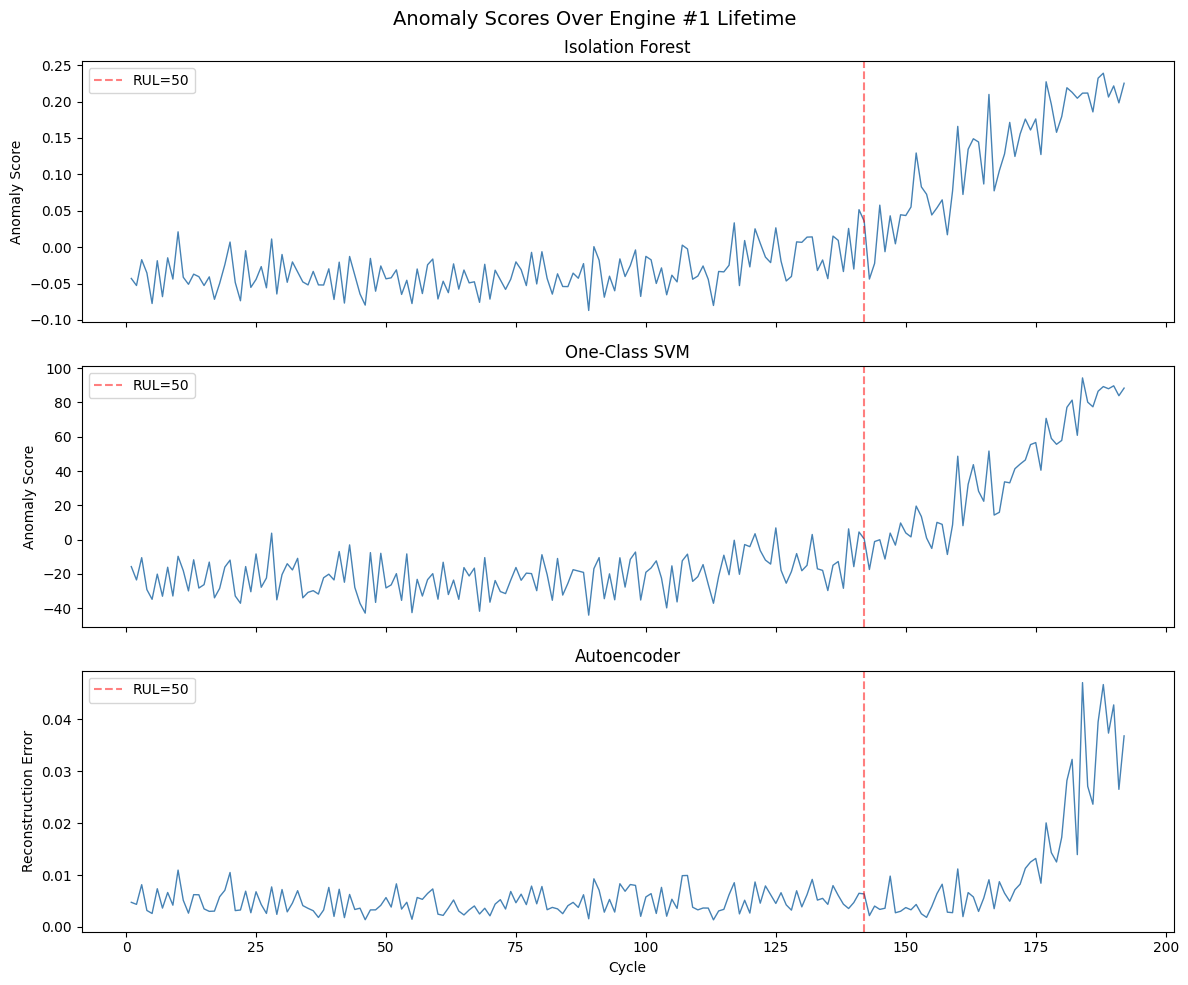

Saved: results/anomaly_scores_engine1.png


In [8]:

# Plot 1: Anomaly scores over engine lifetime (Engine #1)

engine_1 = test_data[test_data['engine_id'] == 1].copy()
e1_idx = engine_1.index
 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Anomaly Scores Over Engine #1 Lifetime', fontsize=14)
 

# Isolation Forest scores (flip sign higher = more anomalous)

axes[0].plot(engine_1['cycle'], -iso_scores[e1_idx], color='steelblue', linewidth=1)
axes[0].set_ylabel('Anomaly Score')
axes[0].set_title('Isolation Forest')
axes[0].axvline(x=engine_1['cycle'].max() - ANOMALY_THRESHOLD,
                color='red', linestyle='--', alpha=0.5, label=f'RUL={ANOMALY_THRESHOLD}')
axes[0].legend()
 

# One-Class SVM scores (flip sign)

axes[1].plot(engine_1['cycle'], -svm_scores[e1_idx], color='steelblue', linewidth=1)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('One-Class SVM')
axes[1].axvline(x=engine_1['cycle'].max() - ANOMALY_THRESHOLD,
                color='red', linestyle='--', alpha=0.5, label=f'RUL={ANOMALY_THRESHOLD}')
axes[1].legend()
 

# Autoencoder reconstruction error

axes[2].plot(engine_1['cycle'], ae_scores[e1_idx], color='steelblue', linewidth=1)
axes[2].set_ylabel('Reconstruction Error')
axes[2].set_title('Autoencoder')
axes[2].set_xlabel('Cycle')
axes[2].axvline(x=engine_1['cycle'].max() - ANOMALY_THRESHOLD,
                color='red', linestyle='--', alpha=0.5, label=f'RUL={ANOMALY_THRESHOLD}')
axes[2].legend()
 
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\anomaly_scores_engine1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/anomaly_scores_engine1.png")

## Confusion Matrices

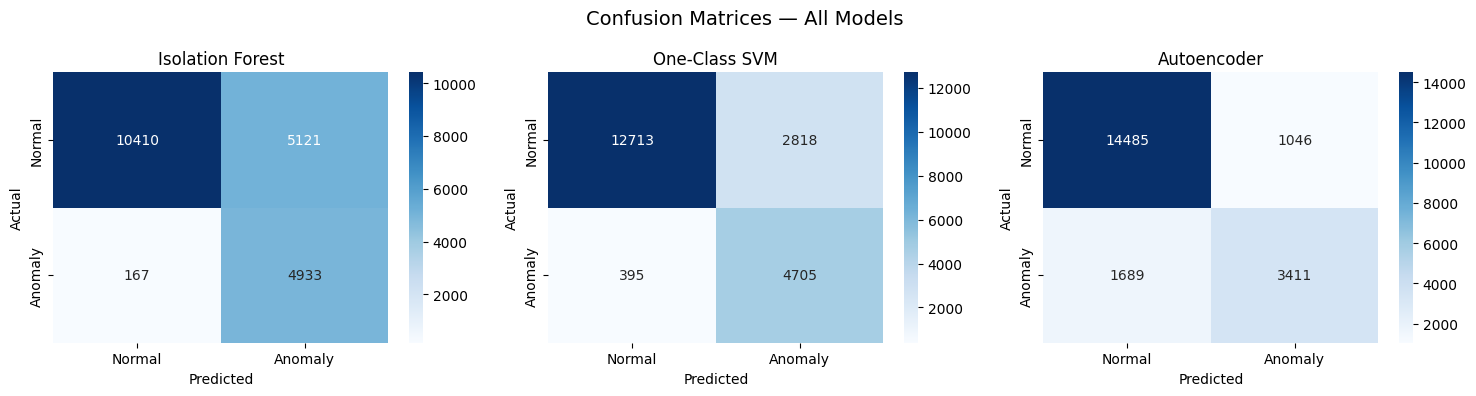

Saved: results/confusion_matrices.png


In [9]:

# Plot 2: Confusion matrices for all three models

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14)
 
for ax, pred, name in zip(axes,
                            [iso_pred, svm_pred, ae_pred],
                            ['Isolation Forest', 'One-Class SVM', 'Autoencoder']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
 
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/confusion_matrices.png")

## Autoencoder Training Loss

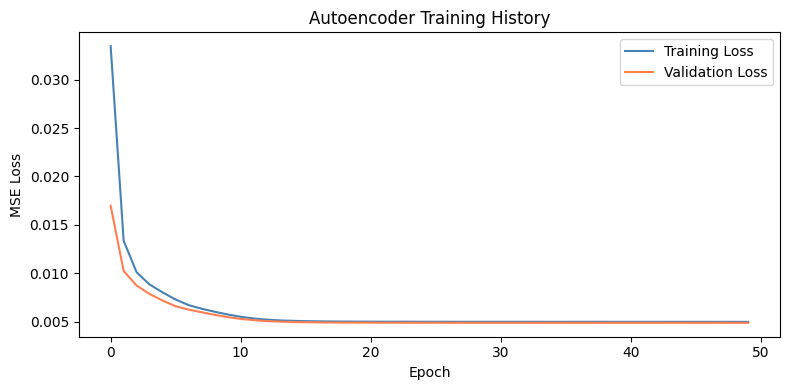

Saved: results/autoencoder_training_loss.png


In [ ]:


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'], label='Training Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Loss', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training History')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\autoencoder_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/autoencoder_training_loss.png")

## ROC-AUC Comparison

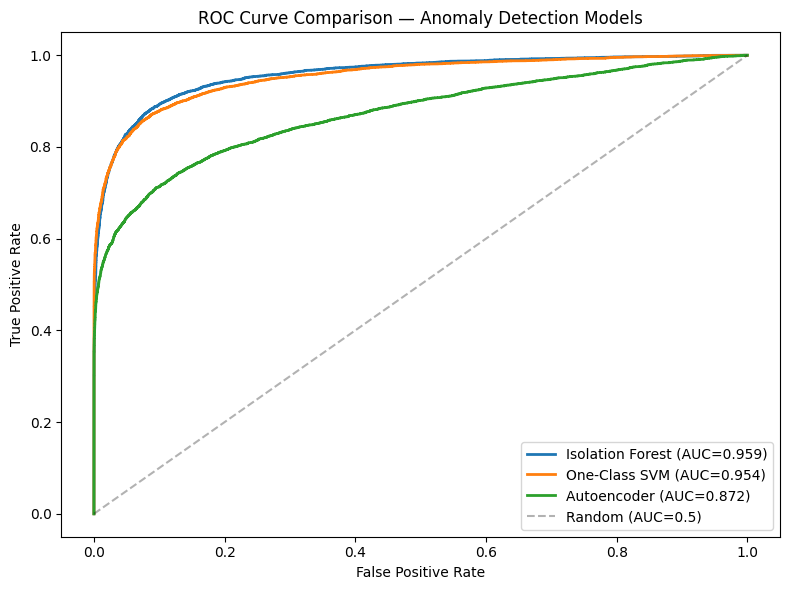

Saved: results/roc_comparison.png


In [11]:

from sklearn.metrics import roc_curve, auc
 
fig, ax = plt.subplots(figsize=(8, 6))
 
# Isolation Forest (negate scores — more negative = more anomalous)
fpr_if, tpr_if, _ = roc_curve(y_test, -iso_scores)
auc_if = auc(fpr_if, tpr_if)
ax.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC={auc_if:.3f})', linewidth=2)
 
# One-Class SVM (negate scores)
fpr_svm, tpr_svm, _ = roc_curve(y_test, -svm_scores)
auc_svm = auc(fpr_svm, tpr_svm)
ax.plot(fpr_svm, tpr_svm, label=f'One-Class SVM (AUC={auc_svm:.3f})', linewidth=2)
 
# Autoencoder (higher error = more anomalous, no need to negate)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
auc_ae = auc(fpr_ae, tpr_ae)
ax.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={auc_ae:.3f})', linewidth=2)
 
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Anomaly Detection Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\results\roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/roc_comparison.png")

# Saving Anomaly Scores


In [12]:

test_data['iso_forest_score'] = -iso_scores        # Higher = more anomalous
test_data['svm_score'] = -svm_scores               # Higher = more anomalous
test_data['autoencoder_score'] = ae_scores         # Higher = more anomalous
test_data['iso_forest_pred'] = iso_pred
test_data['svm_pred'] = svm_pred
test_data['autoencoder_pred'] = ae_pred
 
test_data.to_csv(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\anomaly_results.csv', index=False)
print("Saved anomaly results to: data/anomaly_results.csv")
 
# Save the autoencoder model
model.save(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\Spacecraft-Anomaly-Detection\data\autoencoder_model.keras')
print("Saved autoencoder model to: data/autoencoder_model.keras")
 
# Summary table
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
summary = pd.DataFrame({
    'Model': ['Isolation Forest', 'One-Class SVM', 'Autoencoder'],
    'ROC-AUC': [auc_if, auc_svm, auc_ae],
    'Anomalies Detected': [iso_pred.sum(), svm_pred.sum(), ae_pred.sum()],
    'True Anomalies': [y_test.sum(), y_test.sum(), y_test.sum()]
})
print(summary.to_string(index=False))

Saved anomaly results to: data/anomaly_results.csv
Saved autoencoder model to: data/autoencoder_model.keras

MODEL COMPARISON SUMMARY
           Model  ROC-AUC  Anomalies Detected  True Anomalies
Isolation Forest 0.958575               10054            5100
   One-Class SVM 0.953994                7523            5100
     Autoencoder 0.872218                4457            5100
